# Pakistan Population Census 2017 **EDA**

## Import Libraries
Load required libraries for analysis and visualization.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 📂 Load Dataset

We load the dataset and preview its structure.

In [5]:
df = pd.read_csv("sub-division_population_of_pakistan.csv")

print("Shape:", df.shape)
df.head()

Shape: (528, 21)


,PROVINCE,DIVISION,DISTRICT,SUB DIVISION,AREA (sq.km),ALL SEXES (RURAL),MALE (RURAL),FEMALE (RURAL),TRANSGENDER (RURAL),SEX RATIO (RURAL),...,POPULATION 1998 (RURAL),ANNUAL GROWTH RATE (RURAL),ALL SEXES (URBAN),MALE (URBAN),FEMALE (URBAN),TRANSGENDER (URBAN),SEX RATIO (URBAN),AVG HOUSEHOLD SIZE (URBAN),POPULATION 1998 (URBAN),ANNUAL GROWTH RATE (URBAN)
0,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,BAHAWALNAGAR TEHSIL,1729.0,619550,316864,302644,42,104.70,...,407768,2.22,193840,98391,95402,47,103.13,6.02,133785,1.97
1,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,CHISHTIAN TEHSIL,1500.0,540342,273788,266500,54,102.73,...,395983,1.65,149424,75546,73851,27,102.30,6.01,102287,2.01
2,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,FORT ABBAS TEHSIL,2536.0,361240,182655,178541,44,102.30,...,250959,1.93,61528,31360,30150,18,104.01,6.00,34637,3.06
3,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,HAROONABAD TEHSIL,1295.0,382115,192278,189808,29,101.30,...,297343,1.33,142600,71345,71236,19,100.15,6.02,84424,2.79
4,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,MINCHINABAD TEHSIL,1818.0,452723,231506,221178,39,104.67,...,316593,1.90,72294,36694,35590,10,103.10,6.34,37668,3.48


## 🔍 Data Overview

We examine the dataset structure, data types, and missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PROVINCE                    528 non-null    object 
 1   DIVISION                    528 non-null    object 
 2   DISTRICT                    528 non-null    object 
 3   SUB DIVISION                528 non-null    object 
 4   AREA (sq.km)                528 non-null    float64
 5   ALL SEXES (RURAL)           528 non-null    int64  
 6   MALE (RURAL)                528 non-null    int64  
 7   FEMALE (RURAL)              528 non-null    int64  
 8   TRANSGENDER (RURAL)         528 non-null    int64  
 9   SEX RATIO (RURAL)           528 non-null    float64
 10  AVG HOUSEHOLD SIZE (RURAL)  528 non-null    float64
 11  POPULATION 1998 (RURAL)     528 non-null    int64  
 12  ANNUAL GROWTH RATE (RURAL)  528 non-null    float64
 13  ALL SEXES (URBAN)           528 non

In [ ]:
df.isnull().sum()

,0
PROVINCE,0
DIVISION,0
DISTRICT,0
SUB DIVISION,0
AREA (sq.km),0
ALL SEXES (RURAL),0
MALE (RURAL),0
FEMALE (RURAL),0
TRANSGENDER (RURAL),0
SEX RATIO (RURAL),0


### ✅ Observations
- No missing values present
- Some columns contain zero values (valid cases, not missing data)

## Feature Engineering
Create variables for density, urbanization, and totals.

In [6]:
df["TOTAL_POPULATION"] = df["ALL SEXES (RURAL)"] + df["ALL SEXES (URBAN)"]
df["POP_DENSITY"] = df["TOTAL_POPULATION"] / df["AREA (sq.km)"]
df["URBAN_RATIO"] = df["ALL SEXES (URBAN)"] / df["TOTAL_POPULATION"]
df["GROWTH_GAP"] = df["ANNUAL GROWTH RATE (URBAN)"] - df["ANNUAL GROWTH RATE (RURAL)"]

## Data Cleaning
Remove unrealistic outliers.

In [7]:
df = df[df["ANNUAL GROWTH RATE (RURAL)"] < 10]
df = df[df["ANNUAL GROWTH RATE (URBAN)"] < 10]
df = df[df["SEX RATIO (URBAN)"] < 150]

## Province Area Share
Relative land distribution.

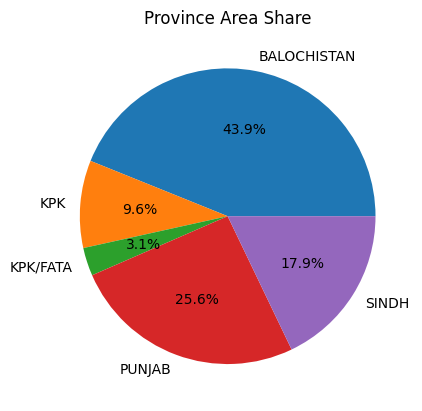

In [8]:
province_area = df.groupby("PROVINCE")["AREA (sq.km)"].sum()

plt.figure()
plt.pie(province_area, labels=province_area.index, autopct='%1.1f%%')
plt.title("Province Area Share")
plt.show()

## 🏙️ Province-Level Analysis

We aggregate population by province.

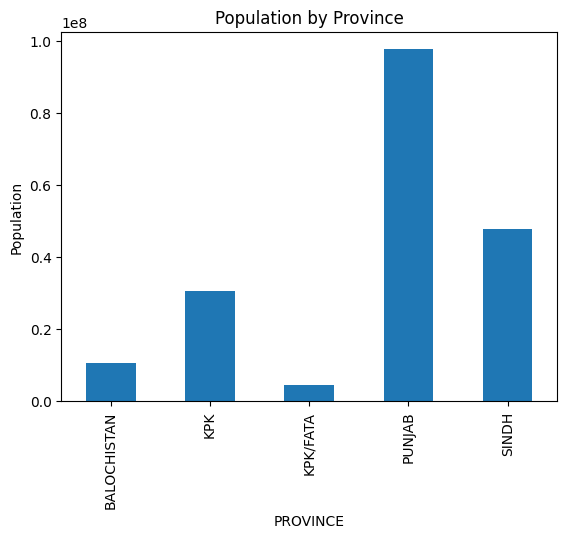

In [ ]:
province_pop = df.groupby("PROVINCE")["TOTAL_POPULATION"].sum()

plt.figure()
province_pop.plot(kind="bar")
plt.title("Population by Province")
plt.ylabel("Population")
plt.show()

### Observation
- Population is uneven across provinces  
- Few provinces dominate total population  
- Most provinces have relatively lower populations  

## Population Density Sub Division
Most densely populated regions.

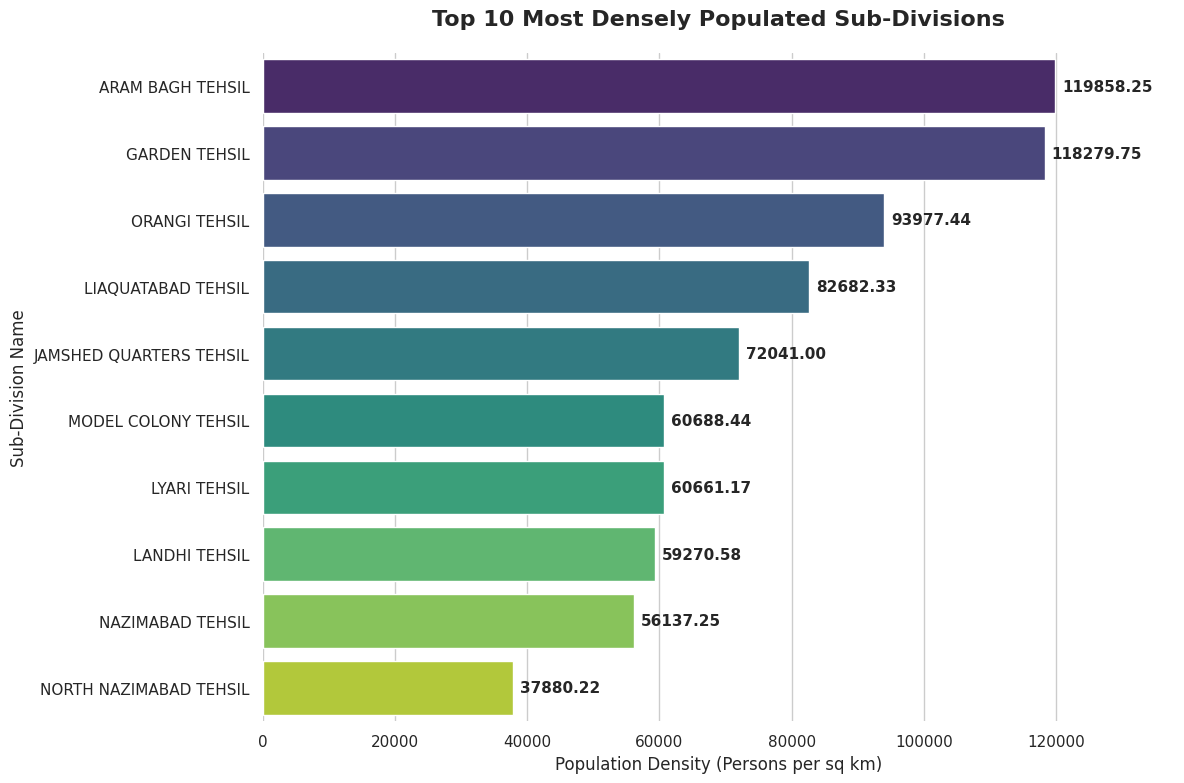

In [32]:

df['POP_DENSITY'] = pd.to_numeric(df['POP_DENSITY'], errors='coerce')
df = df.replace([np.inf, -np.inf], np.nan)
clean_df = df.dropna(subset=['POP_DENSITY'])

top_dense = clean_df.nlargest(10, "POP_DENSITY")

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x="POP_DENSITY",
    y="SUB DIVISION",
    data=top_dense,
    palette="viridis",
    hue="SUB DIVISION",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5, fontsize=11, fontweight='bold')

plt.title("Top 10 Most Densely Populated Sub-Divisions", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Population Density (Persons per sq km)", fontsize=12)
plt.ylabel("Sub-Division Name", fontsize=12)
plt.xlim(0, top_dense["POP_DENSITY"].max() * 1.15)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

###  Observation

- Population is unevenly distributed across provinces  
- A few provinces hold the majority of the population  
- Remaining provinces contribute relatively smaller shares  
- Overall pattern shows strong regional concentration

## Area vs Population
Relationship between size and population.

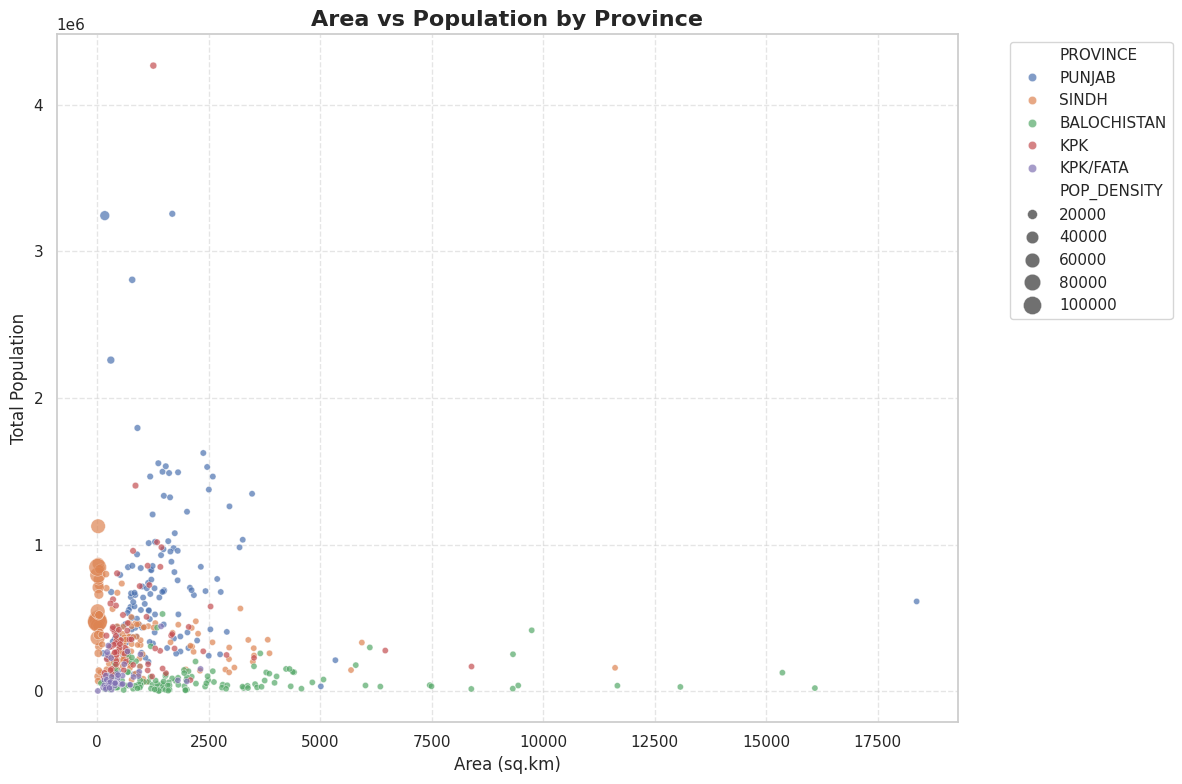

In [33]:


plt.figure(figsize=(12, 8))

sns.scatterplot(
    x="AREA (sq.km)",
    y="TOTAL_POPULATION",
    hue="PROVINCE",
    size="POP_DENSITY",
    sizes=(20, 200),
    alpha=0.7,
    palette="deep",
    data=df
)

plt.title("Area vs Population by Province", fontsize=16, fontweight='bold')
plt.xlabel("Area (sq.km)", fontsize=12)
plt.ylabel("Total Population", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###  Observation

- Punjab shows high population density in relatively smaller areas  
- Balochistan has large areas with low population density  
- A few urban regions (e.g., Karachi) are strong outliers with very high density  
- Weak overall correlation between area and population  
- Population is mainly concentrated in urban clusters  

## Urbanization Index in Province
Urban vs rural distribution.

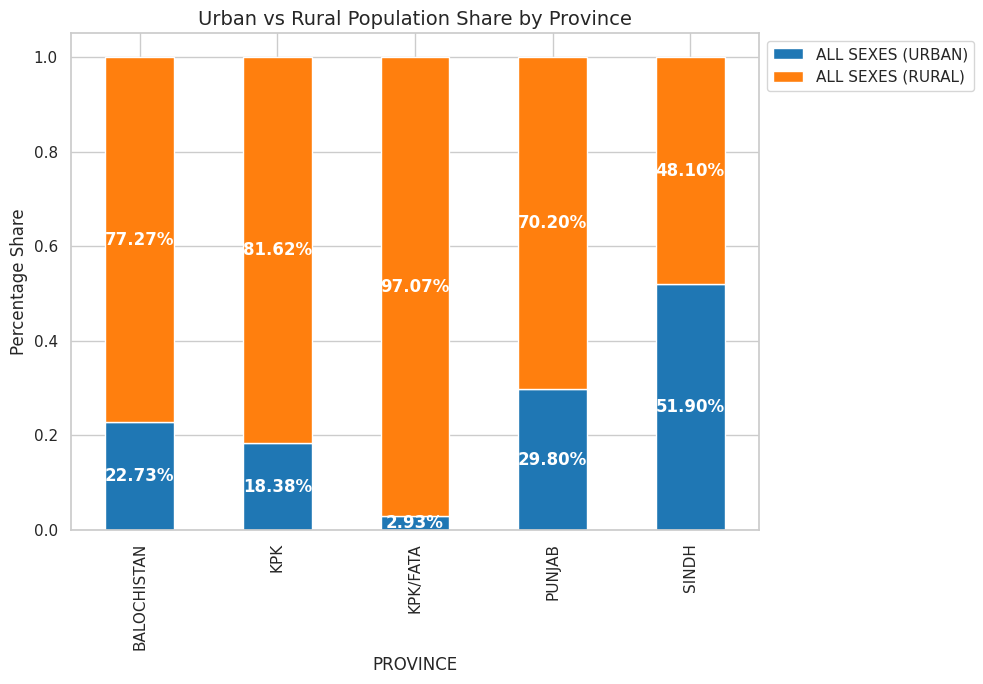

In [34]:


prov = df.groupby("PROVINCE")[["ALL SEXES (URBAN)", "ALL SEXES (RURAL)"]].sum()
prov_pct = prov.div(prov.sum(axis=1), axis=0)

ax = prov_pct.plot(kind="bar", stacked=True, figsize=(10, 7), color=['#1f77b4', '#ff7f0e'])

for c in ax.containers:
    labels = [f'{val:.2%}' for val in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', fontweight='bold', color='white')

plt.title("Urban vs Rural Population Share by Province", fontsize=14)
plt.ylabel("Percentage Share")
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

###  Observation

- Sindh is the most urbanized province with over 50% urban population  
- KPK/FATA shows strong rural dominance (over 80% rural population)  
- Punjab has a balanced mix (~30% urban, ~70% rural)  
- Overall, Pakistan remains predominantly rural except Sindh  

## Growth Comparison in Divisions
Urban vs rural growth trends.

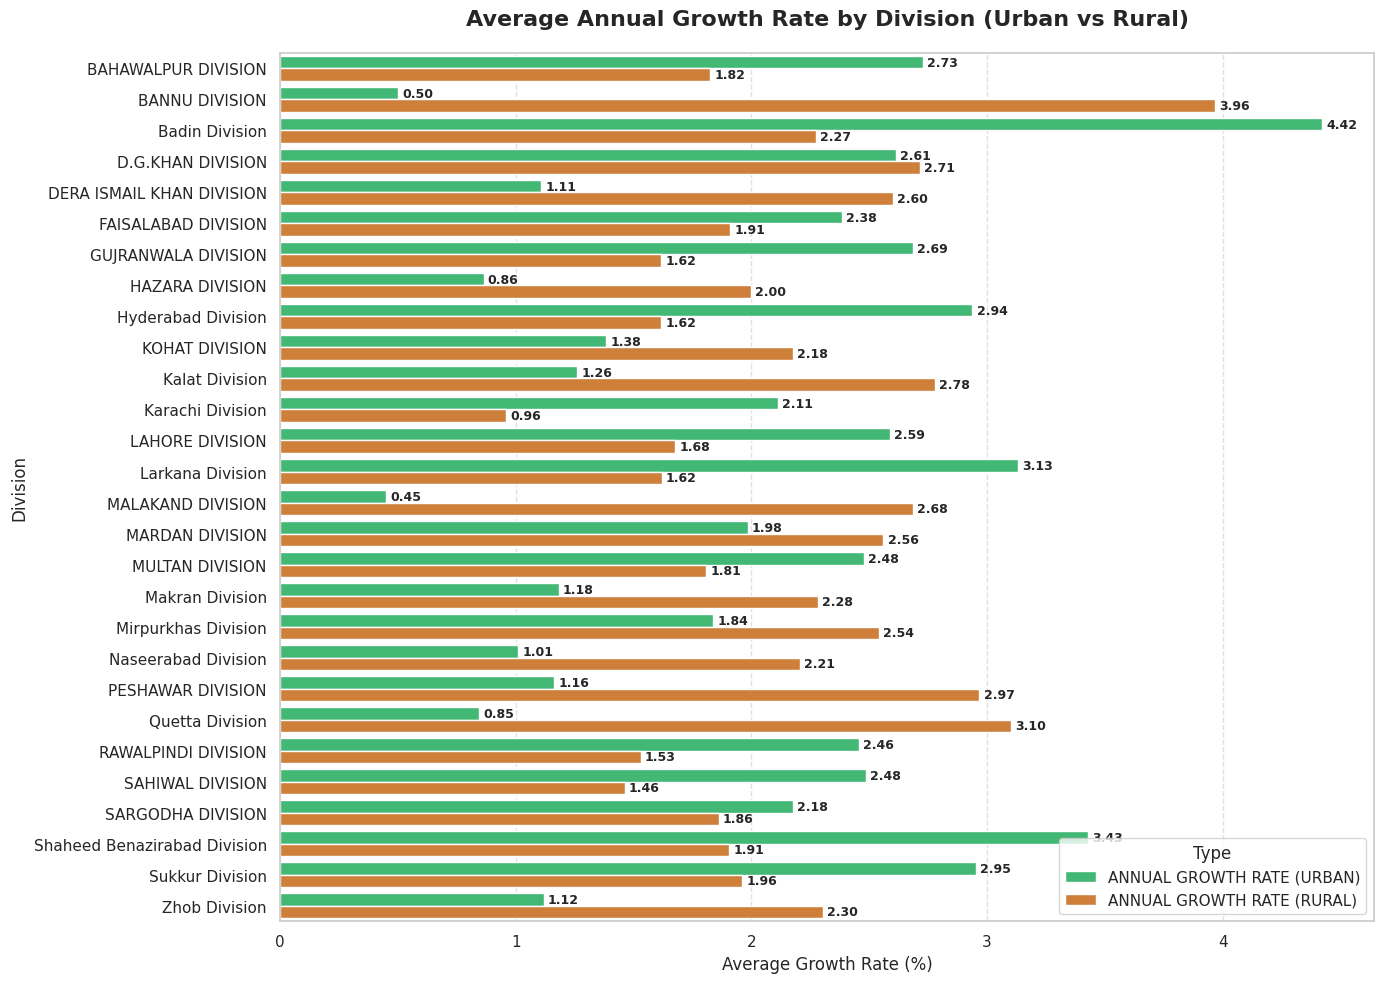

In [35]:
growth = df.groupby("DIVISION")[[
    "ANNUAL GROWTH RATE (URBAN)",
    "ANNUAL GROWTH RATE (RURAL)"
]].mean().reset_index()

growth_melted = growth.melt(
    id_vars="DIVISION",
    var_name="Type",
    value_name="Growth Rate"
)

plt.figure(figsize=(14, 10))

colors = {"ANNUAL GROWTH RATE (URBAN)": "#2ecc71", "ANNUAL GROWTH RATE (RURAL)": "#e67e22"}

ax = sns.barplot(
    data=growth_melted,
    y="DIVISION",
    x="Growth Rate",
    hue="Type",
    palette=colors
)


for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9, fontweight='bold')

plt.title("Average Annual Growth Rate by Division (Urban vs Rural)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Average Growth Rate (%)", fontsize=12)
plt.ylabel("Division", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend(title="Type", loc='lower right')

plt.tight_layout()
plt.show()

###  Observation

- Urban growth is generally higher than rural growth in most divisions, indicating migration toward cities  
- Some areas (e.g., Bannu, Quetta) show higher rural growth than urban  
- Badin has the highest urban growth rate (~4.4%), a clear spike  
- Hazara and Malakand show very low urban growth, indicating stability in rural populations  

## Growth Gap Sub Divsions
Urban minus rural growth.

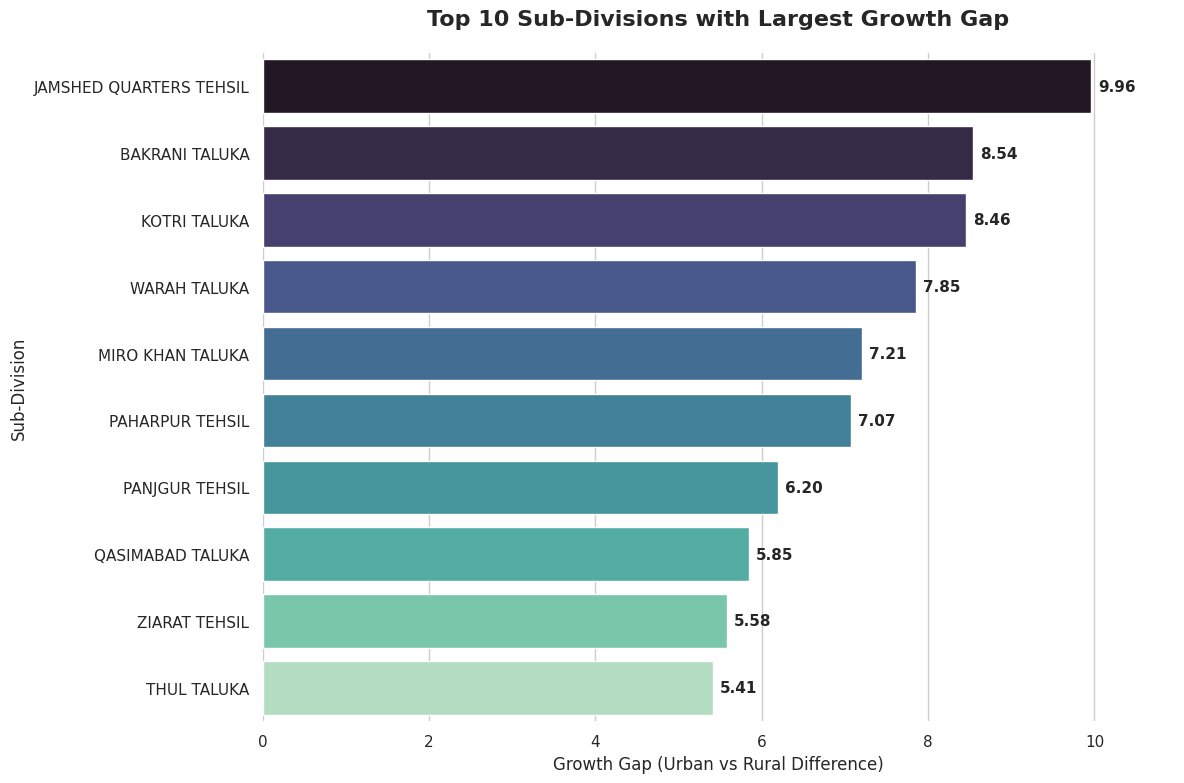

In [36]:

top_gap = df.nlargest(10, "GROWTH_GAP")

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x="GROWTH_GAP",
    y="SUB DIVISION",
    data=top_gap,
    palette="mako",
    hue="SUB DIVISION",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5, fontsize=11, fontweight='bold')

plt.title("Top 10 Sub-Divisions with Largest Growth Gap", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Growth Gap (Urban vs Rural Difference)", fontsize=12)
plt.ylabel("Sub-Division", fontsize=12)

plt.xlim(0, top_gap["GROWTH_GAP"].max() * 1.1)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Growth Relationship
Anuual (Urban vs rural) growth correlation.

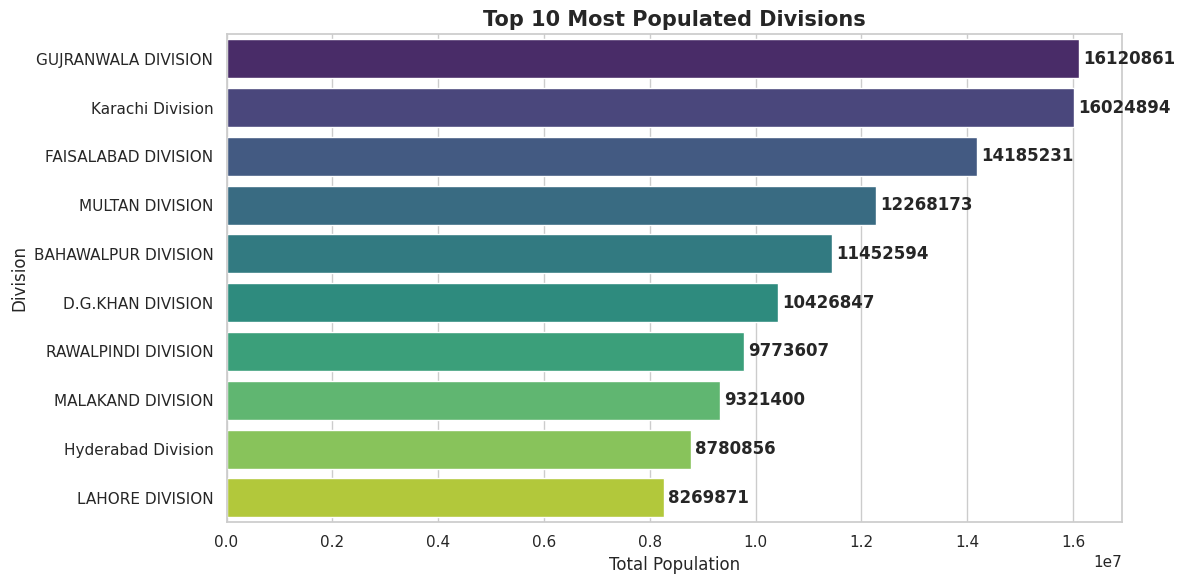

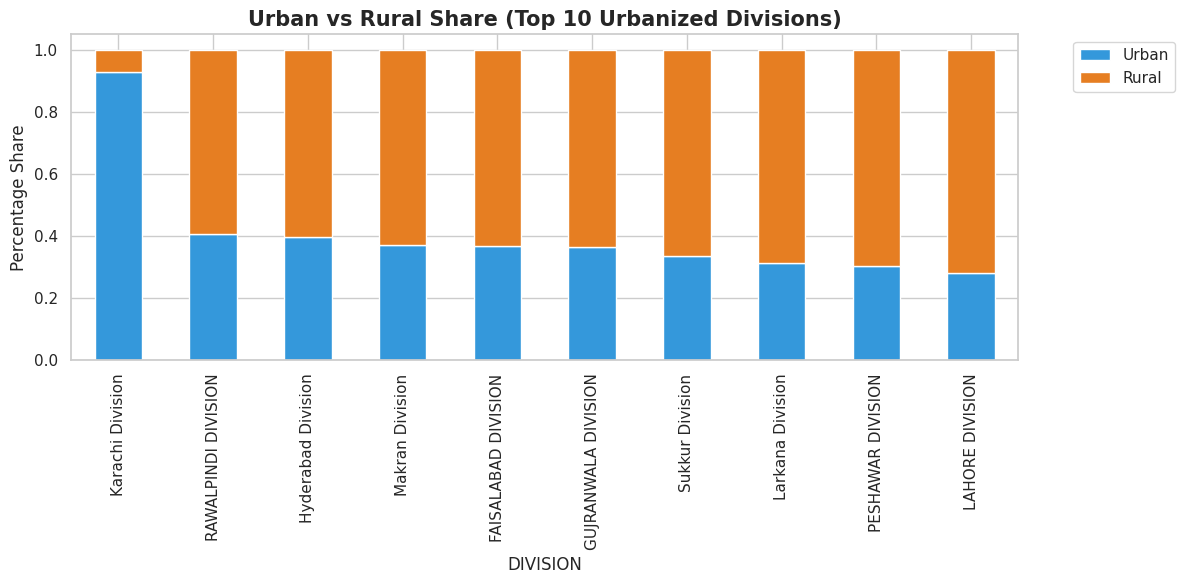

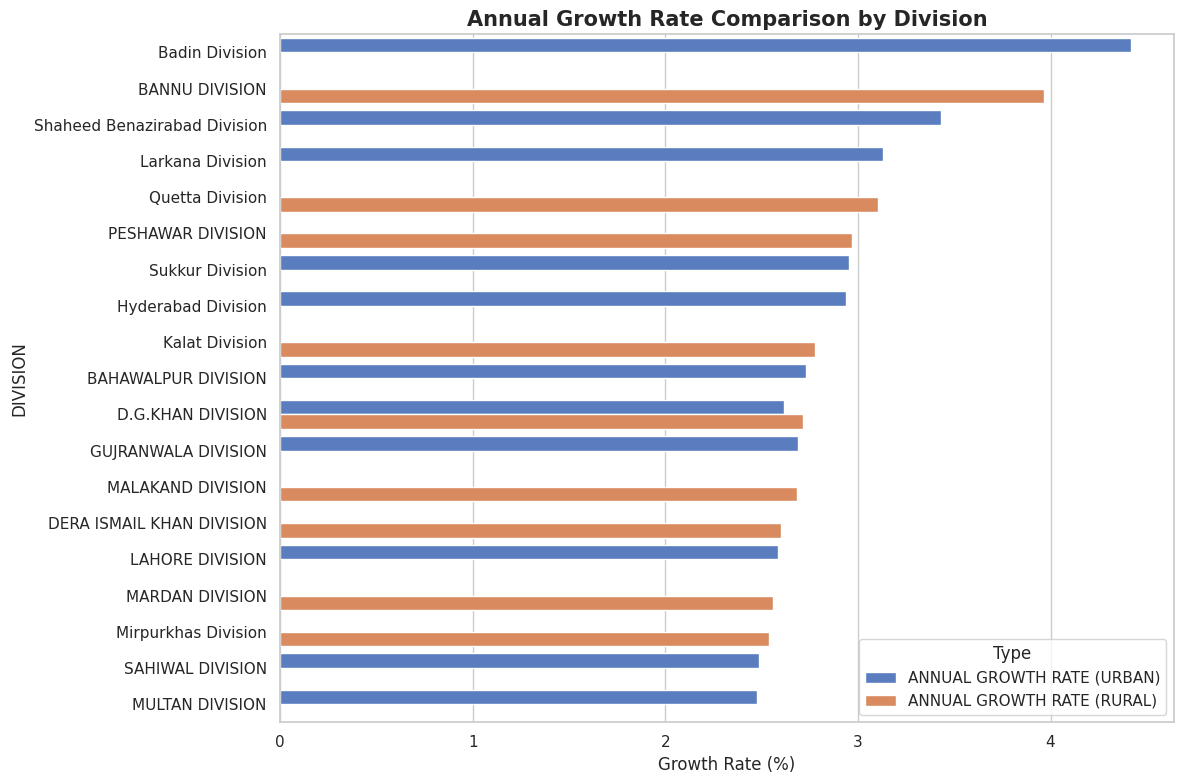

In [38]:

sns.set_theme(style="whitegrid")

div_data = df.groupby("DIVISION").agg({
    "TOTAL_POPULATION": "sum",
    "ALL SEXES (URBAN)": "sum",
    "ALL SEXES (RURAL)": "sum",
    "ANNUAL GROWTH RATE (URBAN)": "mean",
    "ANNUAL GROWTH RATE (RURAL)": "mean"
}).reset_index()

plt.figure(figsize=(12, 6))
top_10_div = div_data.nlargest(10, "TOTAL_POPULATION")
ax1 = sns.barplot(data=top_10_div, x="TOTAL_POPULATION", y="DIVISION", palette="viridis", hue="DIVISION", legend=False)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f', padding=3, fontweight='bold')

plt.title("Top 10 Most Populated Divisions", fontsize=15, fontweight='bold')
plt.xlabel("Total Population")
plt.ylabel("Division")
plt.tight_layout()
plt.show()

div_data['URBAN_PCT'] = div_data['ALL SEXES (URBAN)'] / div_data['TOTAL_POPULATION']
div_data['RURAL_PCT'] = div_data['ALL SEXES (RURAL)'] / div_data['TOTAL_POPULATION']

div_share = div_data.set_index("DIVISION")[['URBAN_PCT', 'RURAL_PCT']].sort_values("URBAN_PCT", ascending=False).head(10)

ax2 = div_share.plot(kind="bar", stacked=True, figsize=(12, 6), color=['#3498db', '#e67e22'])
plt.title("Urban vs Rural Share (Top 10 Urbanized Divisions)", fontsize=15, fontweight='bold')
plt.ylabel("Percentage Share")
plt.legend(["Urban", "Rural"], bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

growth_melted = div_data.melt(
    id_vars="DIVISION",
    value_vars=["ANNUAL GROWTH RATE (URBAN)", "ANNUAL GROWTH RATE (RURAL)"],
    var_name="Type",
    value_name="Growth Rate"
).nlargest(20, "Growth Rate")

plt.figure(figsize=(12, 8))
sns.barplot(data=growth_melted, y="DIVISION", x="Growth Rate", hue="Type", palette="muted")
plt.title("Annual Growth Rate Comparison by Division", fontsize=15, fontweight='bold')
plt.xlabel("Growth Rate (%)")
plt.tight_layout()
plt.show()

### Observation

- Lahore and Karachi are the largest population centers  
- Karachi is highly urbanized (~90%+ urban population)  
- Other divisions (e.g., Bahawalpur, D.G. Khan) are mostly rural  
- Urban growth generally exceeds rural growth, indicating migration to cities  

##3. Gender Analysis
## Transgender Distribution on Province Level
Urban vs rural comparison.

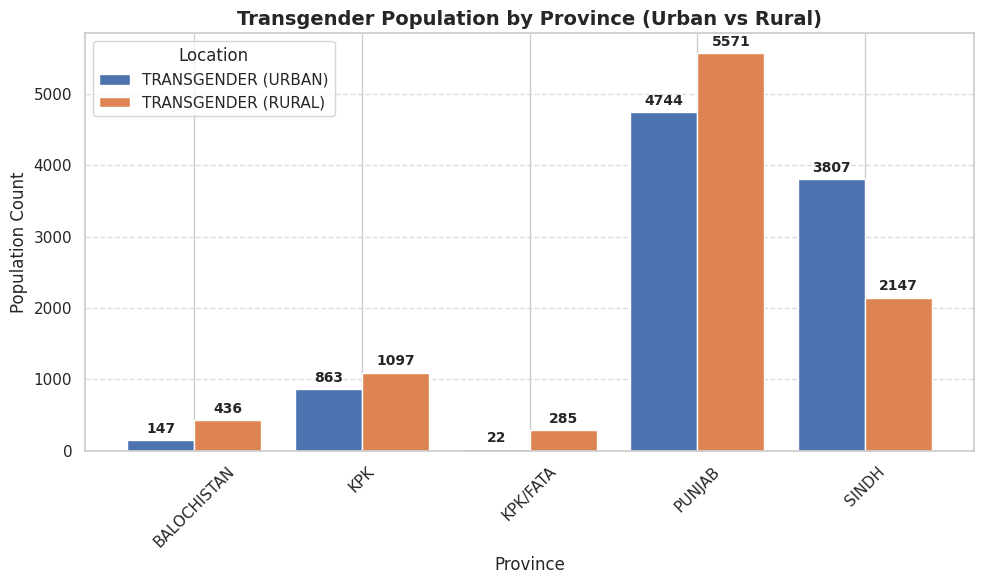

In [39]:


tg = df.groupby("PROVINCE")[["TRANSGENDER (URBAN)", "TRANSGENDER (RURAL)"]].sum()

ax = tg.plot(kind="bar", figsize=(10, 6), width=0.8)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.title("Transgender Population by Province (Urban vs Rural)", fontsize=14, fontweight='bold')
plt.ylabel("Population Count")
plt.xlabel("Province")
plt.xticks(rotation=45)
plt.legend(title="Location")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **Observation**

- Punjab has the highest transgender population overall  
- Sindh is urban-dominant for transgender population  
- Punjab and KPK are rural-dominant  
- Balochistan and KPK/FATA show very low counts (possible underreporting)  

## Sex Ratio Heatmap
Detect gender imbalance.

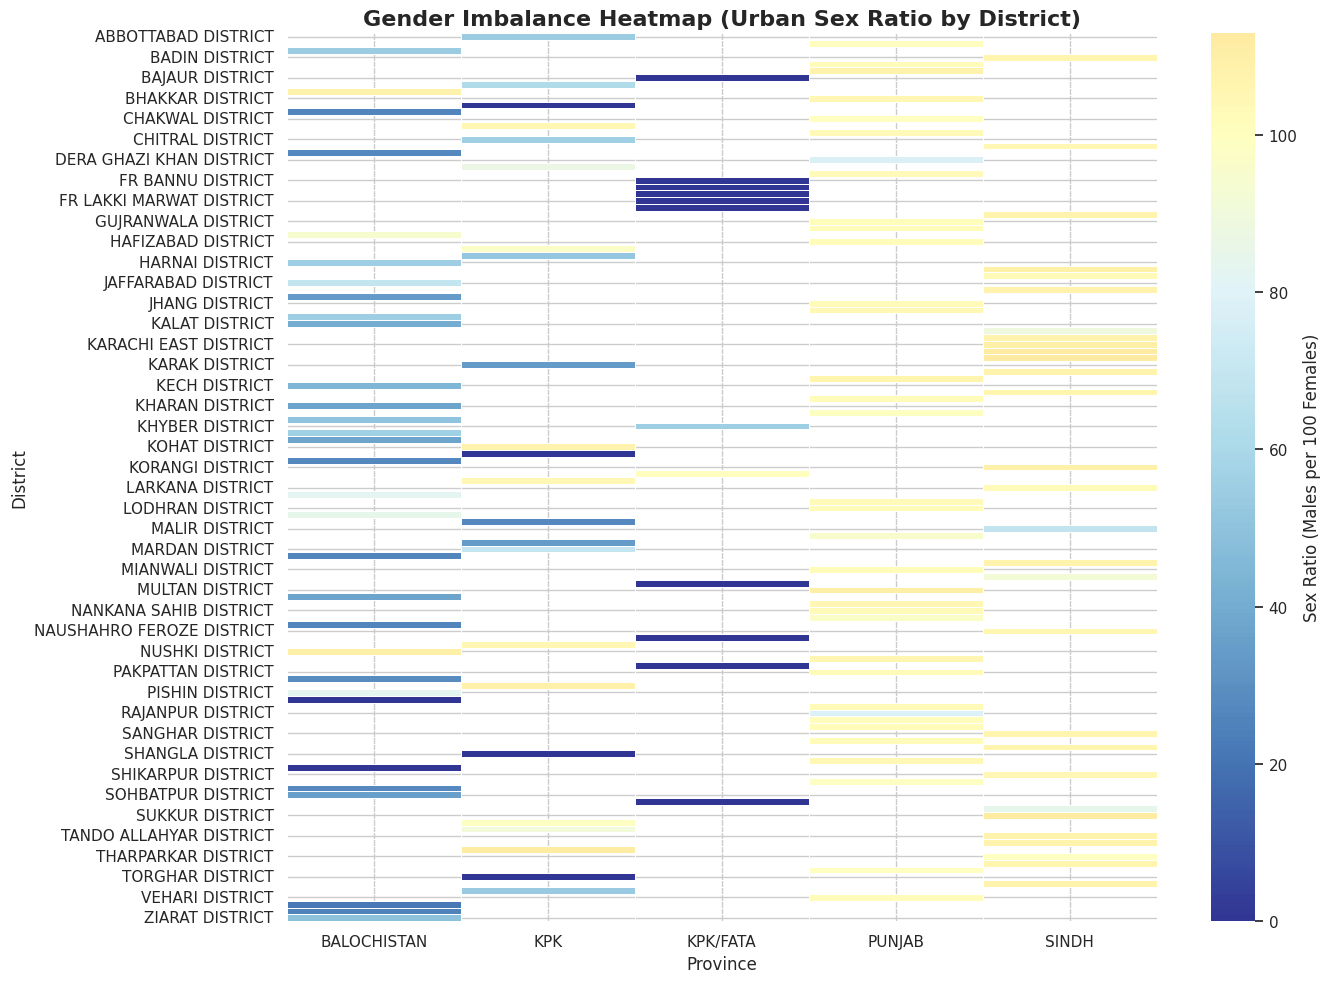

In [40]:


pivot = df.pivot_table(
    values="SEX RATIO (URBAN)",
    index="DISTRICT",
    columns="PROVINCE",
    aggfunc='mean'
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    pivot,
    cmap="RdYlBu_r",
    annot=False,
    linewidths=.5,
    cbar_kws={'label': 'Sex Ratio (Males per 100 Females)'},
    center=100
)

plt.title("Gender Imbalance Heatmap (Urban Sex Ratio by District)", fontsize=16, fontweight='bold')
plt.xlabel("Province", fontsize=12)
plt.ylabel("District", fontsize=12)

plt.tight_layout()
plt.show()

### **Observation**

- Higher ratios indicate male dominance; lower ratios suggest relatively balanced or higher female share  
- Sindh and Punjab urban districts mostly show slight male majority (100–110 ratio)  
- Some remote areas (KPK, Balochistan) show extreme high ratios (possible migration or data gaps)  
- Missing/white areas indicate unavailable or unreported data  

##⏳ 5. Historical Change

## Population Growth
Change since 1998.

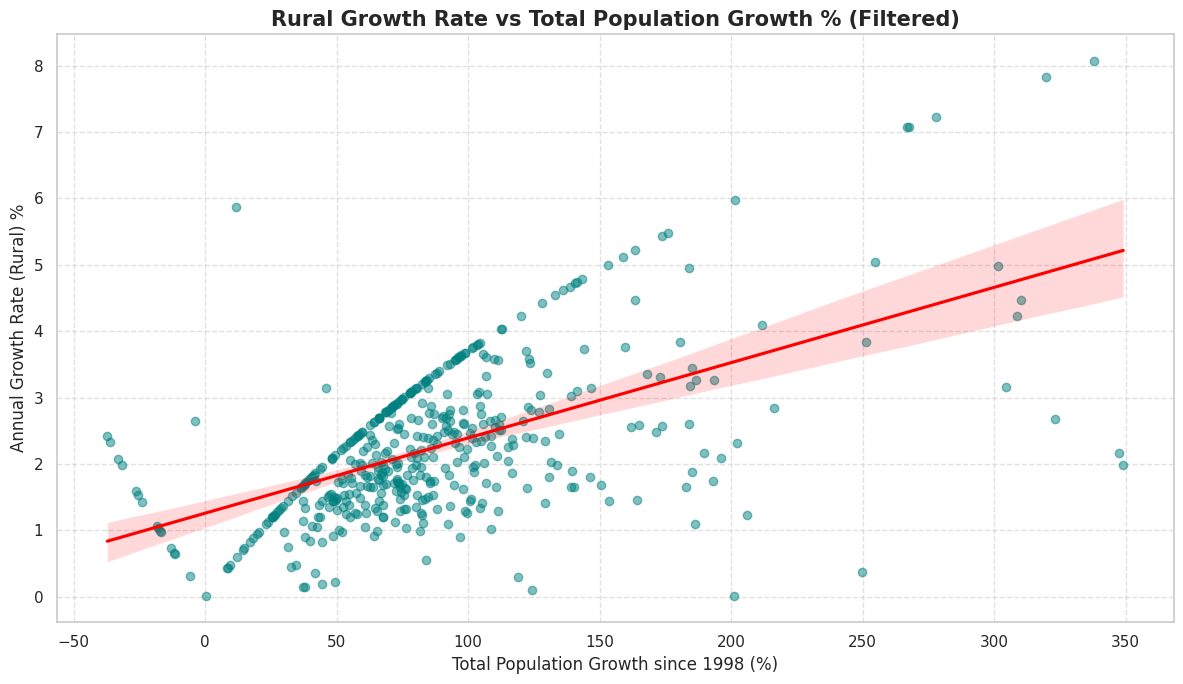

In [41]:


df["POP_GROWTH_%"] = (
    (df["TOTAL_POPULATION"] - df["POPULATION 1998 (RURAL)"]) /
    df["POPULATION 1998 (RURAL)"].replace(0, np.nan)
) * 100

threshold = df["POP_GROWTH_%"].quantile(0.95)
filtered_df = df[df["POP_GROWTH_%"] < threshold]

plt.figure(figsize=(12, 7))

sns.regplot(
    x="POP_GROWTH_%",
    y="ANNUAL GROWTH RATE (RURAL)",
    data=filtered_df,
    scatter_kws={'alpha':0.5, 'color':'teal'},
    line_kws={'color':'red'}
)

plt.title("Rural Growth Rate vs Total Population Growth % (Filtered)", fontsize=15, fontweight='bold')
plt.xlabel("Total Population Growth since 1998 (%)", fontsize=12)
plt.ylabel("Annual Growth Rate (Rural) %", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### **Observation**

- Removing extreme outliers reveals the true data distribution  
- Positive trend: higher total growth aligns with higher rural growth rates  
- Many areas cluster around 0% growth (low growth or missing data)  
- Most regions fall within the 0%–300% growth range  

##🧠 Hypothesis Testing

## Infrastructure Hypothesis Urban Province Wise
Density vs household size.

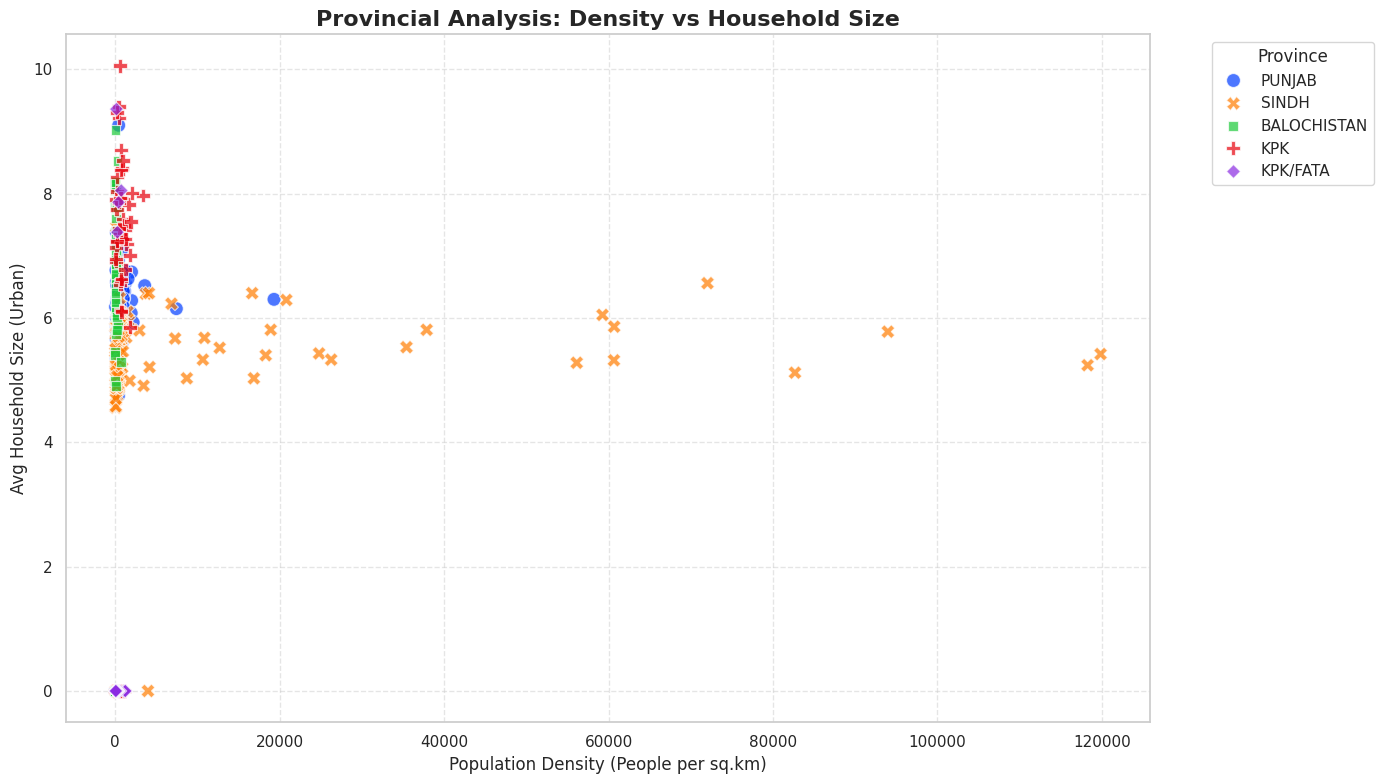

In [43]:

plt.figure(figsize=(14, 8))

sns.scatterplot(
    x="POP_DENSITY",
    y="AVG HOUSEHOLD SIZE (URBAN)",
    hue="PROVINCE",
    style="PROVINCE",
    s=100,
    alpha=0.7,
    palette="bright",
    data=df
)

plt.title("Provincial Analysis: Density vs Household Size", fontsize=16, fontweight='bold')
plt.xlabel("Population Density (People per sq.km)", fontsize=12)
plt.ylabel("Avg Household Size (Urban)", fontsize=12)
plt.legend(title="Province", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### **Observation**

- Punjab & Sindh show higher population density (major urban centers)  
- Balochistan has low density but relatively large household sizes (6–8)  
- Household size remains fairly consistent (4–7) despite density changes  
- Indicates larger families even in high-density urban areas  

## Gender Parity
Urban vs rural distribution.

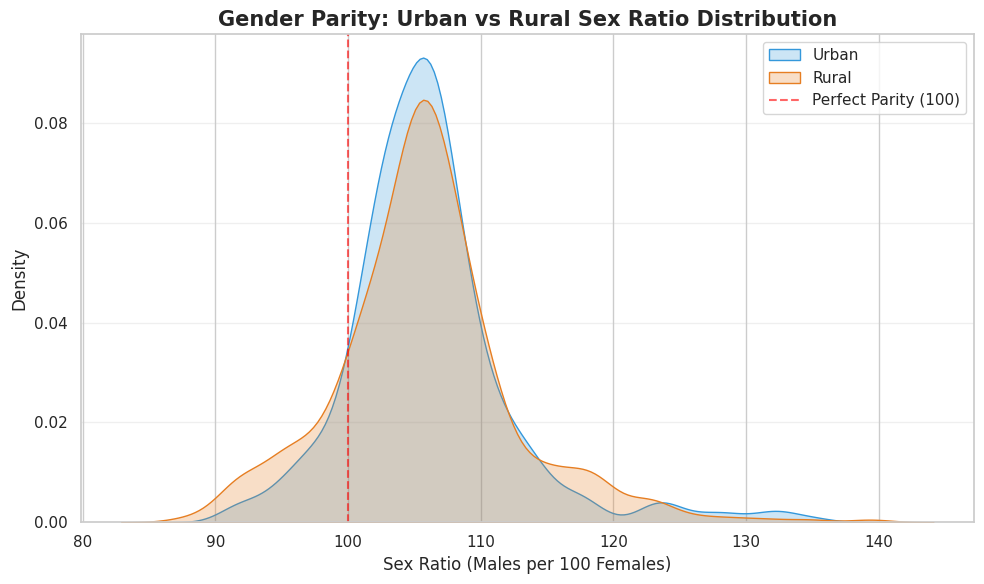

In [44]:

plt.figure(figsize=(10, 6))

filtered_urban = df[df["SEX RATIO (URBAN)"] > 0]["SEX RATIO (URBAN)"]
filtered_rural = df[df["SEX RATIO (RURAL)"] > 0]["SEX RATIO (RURAL)"]

sns.kdeplot(filtered_urban, fill=True, label="Urban", color="#3498db", bw_adjust=0.8)
sns.kdeplot(filtered_rural, fill=True, label="Rural", color="#e67e22", bw_adjust=0.8)

plt.axvline(100, color='red', linestyle='--', alpha=0.6, label='Perfect Parity (100)')

plt.title("Gender Parity: Urban vs Rural Sex Ratio Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Sex Ratio (Males per 100 Females)")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### **Observation**

- Rural areas show consistent sex ratios (sharp, high peak)  
- Urban areas have more variation in sex ratios (flatter distribution)  
- Some cities show male dominance due to migration  
- Zero peak indicates missing urban data; filtering improves clarity  

# **Overall Conclusion: Pakistan Census 2017 Data Analysis**

### Key Insights
- Population is heavily concentrated in a few provinces, especially Punjab and urban Sindh  
- Urban areas are growing faster than rural areas due to migration  
- Large regions (e.g., Balochistan) remain sparsely populated  
- Noticeable gender imbalance, with more males than females  
- Urban housing faces pressure due to large household sizes  

### Major Challenges
- Uneven regional development  
- High urban population density  
- Strain on infrastructure and resources  
- Gaps in data quality and reporting  

### Recommendations
- Promote vertical housing and better urban planning  
- Invest in rural development to reduce migration pressure  
- Improve census data collection systems  

### Final Note
- Pakistan is rapidly urbanizing, requiring balanced and data-driven policy planning  